<a href="https://colab.research.google.com/github/Meghnashankr23/3DVSS_June2026/blob/main/Articulated_Human_Hands/Articulated_Human_Hands.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mano Model Visualization and Animation

This notebook demonstrates how to load, manipulate, visualize and animate the Mano hand model using Python libraries like `manopth`, `trimesh`, and `matplotlib`. It covers setting up the environment, adjusting body shape and pose parameters, and creating interactive 3D animations.

**Pose and Shape Variations**


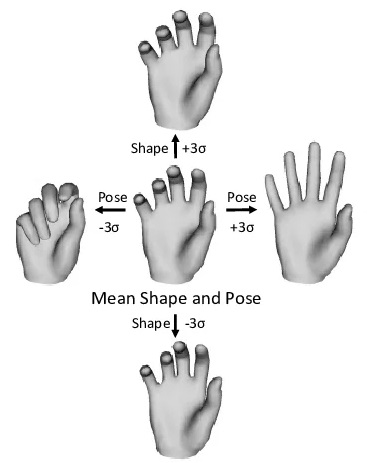

Image Source : https://www.researchgate.net/profile/Dan-Casas-2/publication/334434770/figure/fig1/AS:806300199968770@1569248356863/llustration-of-MANO-hand-model-left-that-is-augmented-with-our-collision-proxies-top.png

### **Initial Setup:**

This cell installs necessary Python libraries: `manopth` for Mano model generation functionality, `chumpy` to properly extract model file (.pkl) data without any errors  and `trimesh` for 3D mesh processing and visualization.
The cell also checks for preexisting downloads and does not download again.

In [ ]:
import os

!cd /content

# Function to check if a package is installed
def is_package_installed(package_name):
    import importlib.util
    spec = importlib.util.find_spec(package_name)
    return spec is not None

# 1. Install patched chumpy to prevent python 3.10/3.11 breakages
if not is_package_installed('chumpy'):
    print('chumpy not found, installing...')
    !pip install git+https://github.com/mattloper/chumpy.git@9b045ff5d6588a24a0bab52c83f032e2ba433e17
else:
    print('chumpy is already installed.')

# 2. Install manopth for PyTorch implementation
if not os.path.exists('/content/manopth'):
    print('manopth directory not found, cloning and installing...')
    !git clone https://github.com/hassony2/manopth.git
    %cd /content/manopth
    !pip install .
else:
    print('manopth directory already exists. Changing directory to manopth.')
    %cd /content/manopth

# 3. Install visualization tool for displaying the 3D hand mesh in Colab
if not is_package_installed('trimesh'):
    print('trimesh not found, installing...')
    !pip install trimesh
else:
    print('trimesh is already installed.')

chumpy is already installed.
manopth directory already exists. Changing directory to manopth.
/content/manopth
trimesh is already installed.


### **Core Library Imports**
This cell imports essential libraries for working with the Mano model, including `manopth.manolayer` for model functionality, `numpy` for numerical operations, and `trimesh` for 3D mesh processing.

In [ ]:
import os
import torch
import numpy as np
from manopth.manolayer import ManoLayer
import trimesh


**MANO Model Files**: The manopth library requires the mano.pkl model files. We load it at appropriate location such  that it is accesible to manopth. Checks have been added to prevent multiple downloads.

In [ ]:
!pip install gdown
import gdown
import os
import time

folder_id = '1YuONC1ze4xAUk7hfKHuCrwE8oKV5_tlW'
mano_root_path = '/content/manopth/mano/' # gdown will create 'models' inside this

target_mano_folder = os.path.join(mano_root_path, 'models')

# Check if the mano models folder already exists and contains files
if os.path.exists(target_mano_folder) and os.listdir(target_mano_folder):
    print(f"Folder '{target_mano_folder}' already exists and contains files. Skipping download.")
else:
    print(f"Downloading MANO model files to {target_mano_folder}...")
    max_retries = 3
    for attempt in range(max_retries):
        try:
            # gdown will create the 'models' folder inside mano_root_path
            gdown.download_folder(id=folder_id, output=mano_root_path, quiet=False, use_cookies=False, remaining_ok=True)

            # After download, verify if the target folder exists and has content
            if os.path.exists(target_mano_folder) and os.listdir(target_mano_folder):
                print(f"Folder downloaded to {target_mano_folder}")
                print("Download successful.")
                break # Exit loop if successful
            else:
                # If gdown didn't throw an error but the folder is empty, something is wrong
                raise Exception("Download appeared to complete but target folder is empty.")
        except Exception as e:
            print(f"Attempt {attempt + 1}/{max_retries} failed: {e}")
            if attempt < max_retries - 1:
                sleep_time = 2 ** attempt * 5 # Exponential backoff: 5, 10, 20 seconds
                print(f"Retrying in {sleep_time} seconds...")
                time.sleep(sleep_time)
            else:
                print(f"All {max_retries} attempts failed. Please check your internet connection or Google Drive access.")

print(f"Final content check in {target_mano_folder}: {os.listdir(target_mano_folder)[:5]}...") # Display first 5 items

Folder '/content/manopth/mano/models' already exists and contains files. Skipping download.
Final content check in /content/manopth/mano/models: ['MANO_LEFT.pkl', 'MANO_RIGHT.pkl']...


### **Code to generate hand articulations**

The code below utilizes the Manolayer function to generate an abstraction to manipulate a Mano based hand model. It takes loads the .pkl file conatining parametric hand model configuration and modifies the shape and pose from inputs.  

In [ ]:
%cd /content/manopth

# 1. Initialize the MANO Layer
# ncomps=45 means the internal PCA matrix expects exactly 45 components for finger joints
mano_layer = ManoLayer(
    mano_root='mano/models',
    use_pca=False,  # whether to use principal components or rotation values
    ncomps=48, # number of principal component values for articulation
    side='right', # right hand mano model
    flat_hand_mean = False # normal pose is a flat hand if set True
)

batch_size = 1

# 2. Shape parameter (Beta): 10 dimensions
betas = torch.zeros(batch_size, 10)

# 3. Create the full combined pose tensor of size 48 (3 Global Orient + 45 Finger PCA)
full_pose = torch.zeros(batch_size, 48)

# 4. Pass arguments positionally.
# Inside the layer: it slices off full_pose[:, :3] for orientation,
# and sends full_pose[:, 3:] (which is exactly 45 elements) to the PCA matrix!
vertices, joints = mano_layer(full_pose, betas)

# 5. Extract numpy arrays for plotting
verts = vertices[0].detach().cpu().numpy()
faces = mano_layer.th_faces.numpy()

print(f"Mesh Vertices successfully generated: {verts.shape}")
print(f"Mesh Faces successfully generated   : {faces.shape}\n")


/content/manopth
Mesh Vertices successfully generated: (778, 3)
Mesh Faces successfully generated   : (1538, 3)



In [ ]:
def generate(verts, faces):
  mesh = trimesh.Trimesh(vertices=verts, faces=faces)
  return mesh

#### **Normal Shape and Pose**

In [ ]:
mesh = generate(verts,faces)
mesh.show()


### **Generate Shape variations**

This cell demonstrates how to adjust the hand's shape using the `betas` parameters.
If we change shape parameters, i.e. betas, we get a variation in the shape of hand. These are principla component values and direct interpretation of effect is difficult. These parameters are learned using non linear optimizations.
The beta vector is a 1x10 dimensional tensor. We set the first and second component to 0 and -15 respectively and visualize the change

In [ ]:
mano_layer1 = ManoLayer(
    mano_root='mano/models',
    use_pca=False,
    ncomps=48,
    side='right',
    flat_hand_mean = False
)

batch_size = 1

# 2. Shape parameter (Beta): 10 dimensions
betas = torch.zeros(batch_size, 10)
betas[0, 0] = 0
betas[0, 1] = -15

full_pose = torch.zeros(batch_size, 48)
new_vertices, new_joints = mano_layer1(full_pose, betas)

# 5. Extract numpy arrays for plotting
new_verts = new_vertices[0].detach().cpu().numpy()
new_faces = mano_layer1.th_faces.numpy()



In [ ]:
new_mesh = generate(new_verts,new_faces)
new_mesh.show()


### **Generate Pose variations**

By Changing the pose variables, i.e. the pose tensor we can change the hand articulation. These contain rotation values or pca values for manipulation. By setting use_pca=False, we can provide the rotation values of each joint. Here we set the pose as index finger pointing pose, through point_pose tensor.  

### **Pointing Pose** ###

In [ ]:
mano_layer2 = ManoLayer(
    mano_root='mano/models',
    use_pca=False,
    ncomps=48,
    side='right',
    flat_hand_mean = False
)

batch_size = 1

# 2. Shape parameter (Beta): 10 dimensions
betas = torch.zeros(batch_size, 10)

In [ ]:
point_pose =  torch.zeros(batch_size, 48)
# 4. Pass arguments positionally.
# Inside the layer: it slices off point_pose[:, :3] for orientation,
# and sends point_pose[:, 3:] (which is exactly 45 elements) to the joint rotation matrix!
point_pose[0, 0:3] = torch.tensor([0.0, 0.0, 0.0])
point_pose[0, 3:] = torch.tensor([
   0.13531354069709778, -0.03972889855504036, -0.16108830273151398, 0.008490411564707756, 0.00900512095540762, -0.661708414554596, -0.007708890363574028, -0.14107191562652588, -0.21745865046977997, -0.2391984760761261, -0.025968819856643677, 0.7652187347412109, -0.13346648216247559, -0.15933099389076233, -0.2862415313720703, -0.026776939630508423, -0.10817168653011322, -0.013231238350272179, -0.40595516562461853, 0.3238948583602905, 0.1672605276107788, -0.17081470787525177, -0.14189507067203522, 0.040919072926044464, -0.19939467310905457, -0.05874693766236305, 0.006916172336786985, -0.28095901012420654, 0.3733741343021393, 1.1286892890930176, -0.13499726355075836, 0.11568336188793182, -0.03602002188563347, -0.13695558905601501, -0.13996127247810364, -0.013958962634205818, 0.27402549982070923, -0.2958167493343353, 0.17678309977054596, -0.0009073885739780962, 0.15817740559577942, 0.19820977747440338, 0.07666298747062683, 0.6213206648826599, -0.32918229699134827])

# Recalculate vertices and joints with the new pose
point_vertices, point_joints = mano_layer2(point_pose, betas)

# Extract numpy arrays for plotting
point_vertices = point_vertices[0].detach().cpu().numpy()
point_faces = mano_layer.th_faces.numpy()

print(f"Mesh Vertices updated and generated: {point_vertices.shape}")
print(f"Mesh Faces updated and generated   : {point_faces.shape}\n")

Mesh Vertices updated and generated: (778, 3)
Mesh Faces updated and generated   : (1538, 3)



In [ ]:
mesh = generate(point_vertices,point_faces)
mesh.show()

### **Create realistic animation from real pose data**

Using a sequence of realistic hand pose data, we  generate an animation of hand articulation. The pose is varied by updating the pose tensor with each frame. We use various jsons containing the pose data. The jsons are sourced from interwild dataset:  https://mks0601.github.io/InterHand2.6M/

**Upload Pose JSON Files for Animation**: For the animation section, a collection of `.json` files is used, each containing hand pose data.
We load it into appropriate location in the following cell.

In [ ]:
import gdown
import os
import time

folder_id = '1k6-a9LthLN_Qc086zsrQAUQ7E-PT2Rj2'
download_root_path = '/content/' # gdown will create 'poses' inside this

target_poses_folder = os.path.join(download_root_path, 'poses')

# Check if the poses folder already exists and contains files
if os.path.exists(target_poses_folder) and os.listdir(target_poses_folder):
    print(f"Folder '{target_poses_folder}' already exists and contains files. Skipping download.")
else:
    print(f"Downloading pose files to {target_poses_folder}...")
    max_retries = 3
    for attempt in range(max_retries):
        try:
            # gdown will create the 'poses' folder inside download_root_path
            gdown.download_folder(id=folder_id, output=download_root_path, quiet=False, use_cookies=False, remaining_ok=True)

            # After download, verify if the target folder exists and has content
            if os.path.exists(target_poses_folder) and os.listdir(target_poses_folder):
                print(f"Folder downloaded to {target_poses_folder}")
                print("Download successful.")
                break # Exit loop if successful
            else:
                # If gdown didn't throw an error but the folder is empty, something is wrong
                raise Exception("Download appeared to complete but target folder is empty.")
        except Exception as e:
            print(f"Attempt {attempt + 1}/{max_retries} failed: {e}")
            if attempt < max_retries - 1:
                sleep_time = 2 ** attempt * 5 # Exponential backoff: 5, 10, 20 seconds
                print(f"Retrying in {sleep_time} seconds...")
                time.sleep(sleep_time)
            else:
                print(f"All {max_retries} attempts failed. Please check your internet connection or Google Drive access.")

print(f"Final content check in {target_poses_folder}: {os.listdir(target_poses_folder)[:5]}...") # Display first 5 items

Folder '/content/poses' already exists and contains files. Skipping download.
Final content check in /content/poses: ['532.json', '445.json', '427.json', '511.json', '490.json']...


In [ ]:
import glob
import json
import time
from PIL import Image
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Path to the folder containing JSON pose files
poses_folder = '/content/poses/'
output_folder = '/content/mano_animation_frames/'
os.makedirs(output_folder, exist_ok=True)

# Get a list of all JSON files in the folder
json_files = sorted(glob.glob(os.path.join(poses_folder, '*.json')))

if not json_files:
    print(f"No JSON files found in {poses_folder}")
else:
    print(f"Found {len(json_files)} pose files. Generating animation frames...")

    frames = []
    # Loop through each JSON file to apply the pose and display the mesh
    for i, json_file in enumerate(json_files):
        print(f"Processing {json_file} ({i+1}/{len(json_files)})...")
        with open(json_file, 'r') as f:
            pose_data = json.load(f)

        # Extract the hand_pose field
        hand_pose_list = pose_data.get('hand_pose')

        if hand_pose_list is None:
            print(f"Warning: 'hand_pose' field not found in {json_file}. Skipping.")
            continue

        if len(hand_pose_list) != 45:
            print(f"Warning: 'hand_pose' in {json_file} has {len(hand_pose_list)} elements, expected 45. Skipping.")
            continue

        # Create a new pose tensor and set the hand_pose components
        current_hand_pose_tensor = torch.zeros(batch_size, 48)
        current_hand_pose_tensor[0, 0:3] = torch.tensor([0.0, 0.0, 0.0]) # Keep global orientation neutral
        current_hand_pose_tensor[0, 3:] = torch.tensor(hand_pose_list, dtype=torch.float32)

        # Recalculate vertices and joints with the new pose using mano_layer2
        anim_vertices, anim_joints = mano_layer2(current_hand_pose_tensor, betas)

        # Extract numpy arrays for plotting
        anim_verts = anim_vertices[0].detach().cpu().numpy()
        anim_faces = mano_layer.th_faces.numpy() # Faces are constant for the model

        # Generate and save the mesh as an image using matplotlib
        fig = plt.figure(figsize=(10, 10))
        ax = fig.add_subplot(111, projection='3d')

        # Plot the mesh
        ax.plot_trisurf(anim_verts[:, 0], anim_verts[:, 1], anim_verts[:, 2],
                        triangles=anim_faces, cmap='viridis', alpha=0.8)

        # Set equal aspect ratio to prevent distortion
        max_range = np.array([anim_verts[:,0].max()-anim_verts[:,0].min(),
                              anim_verts[:,1].max()-anim_verts[:,1].min(),
                              anim_verts[:,2].max()-anim_verts[:,2].min()]).max()
        mid_x = (anim_verts[:,0].max()+anim_verts[:,0].min()) * 0.5
        mid_y = (anim_verts[:,1].max()+anim_verts[:,1].min()) * 0.5
        mid_z = (anim_verts[:,2].max()+anim_verts[:,2].min()) * 0.5
        ax.set_xlim(mid_x - max_range, mid_x + max_range)
        ax.set_ylim(mid_y - max_range, mid_y + max_range)
        ax.set_zlim(mid_z - max_range, mid_z + max_range)

        # Set labels and title (optional)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_zlabel('Z')
        ax.set_title(f'Pose Frame {i+1}')

        # Hide axes for cleaner look
        ax.set_axis_off()

        image_path = os.path.join(output_folder, f'frame_{i:04d}.png')
        plt.savefig(image_path, bbox_inches='tight', pad_inches=0, dpi=100) # Save with no padding
        plt.close(fig) # Close the figure to free memory

        frames.append(Image.open(image_path))

    print("All frames generated. Creating GIF...")
    # Create a GIF from the frames
    if frames:
        first_frame = frames[0]
        gif_path = os.path.join(output_folder, 'mano_animation.gif')
        first_frame.save(gif_path, format='GIF', append_images=frames[1:],
                         save_all=True, duration=100, loop=0)
        print(f"Animation GIF saved to {gif_path}")
    else:
        print("No frames to create GIF.")

    print("Animation process complete.")

Found 50 pose files. Generating animation frames...
Processing /content/poses/400.json (1/50)...
Processing /content/poses/403.json (2/50)...
Processing /content/poses/406.json (3/50)...
Processing /content/poses/409.json (4/50)...
Processing /content/poses/412.json (5/50)...
Processing /content/poses/415.json (6/50)...
Processing /content/poses/418.json (7/50)...
Processing /content/poses/421.json (8/50)...
Processing /content/poses/424.json (9/50)...
Processing /content/poses/427.json (10/50)...
Processing /content/poses/430.json (11/50)...
Processing /content/poses/433.json (12/50)...
Processing /content/poses/436.json (13/50)...
Processing /content/poses/439.json (14/50)...
Processing /content/poses/442.json (15/50)...
Processing /content/poses/445.json (16/50)...
Processing /content/poses/448.json (17/50)...
Processing /content/poses/451.json (18/50)...
Processing /content/poses/454.json (19/50)...
Processing /content/poses/457.json (20/50)...
Processing /content/poses/460.json (2

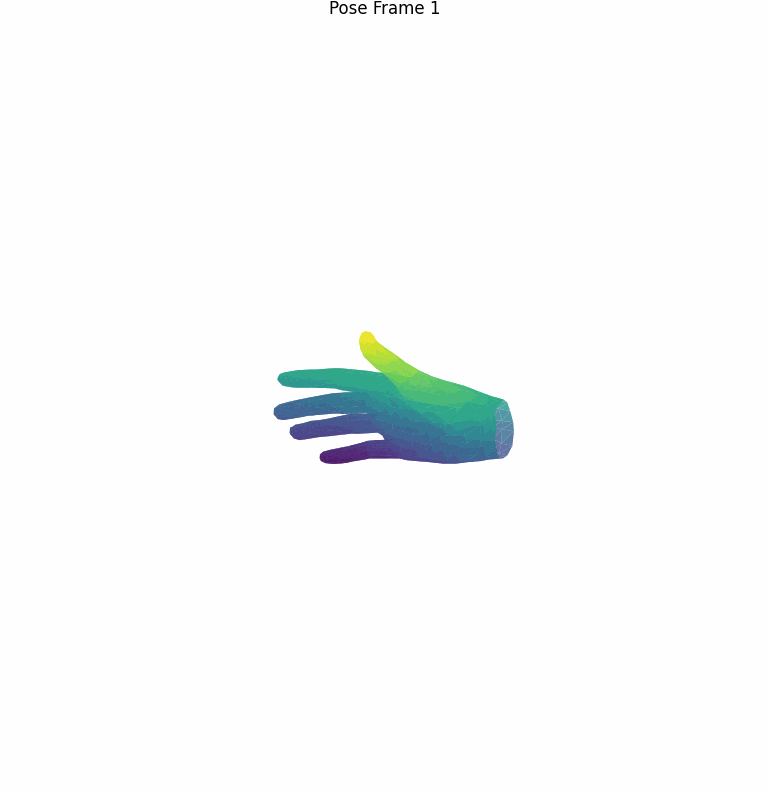

In [ ]:
from IPython.display import Image as DisplayImage
display(DisplayImage(filename=gif_path))